Text Classification with RNN**

##**1.Text Preprocessing, Tokenization, and Sequence Padding**

###**Import Necessaary Library**

In [1]:
!pip install contractions

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 13.9 MB/s eta 0:00:00


In [37]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import contractions



In [38]:
import pandas as pd
import zipfile
import os

# ZIP file name
zip_file_name = 'Spam vs Ham Sms Dataset.zip'

# Extract folder
extract_folder = 'extracted_data'

# Extract the ZIP
with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
    zip_ref.extractall(extract_folder)

print("ZIP extraction complete.\n")

# Correct CSV path
file_path = 'extracted_data/Spam vs Ham Sms Dataset/spamvsham.csv'

# Load dataset
df = pd.read_csv(file_path, encoding='latin-1')

# Keep only required columns
df = df.iloc[:, [0, 1]]

# Rename columns
df.columns = ['label', 'text']

print("Dataset Loaded Successfully!\n")

# Display dataset info
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns)

print("\nFirst 5 rows:")
print(df.head())

ZIP extraction complete.

Dataset Loaded Successfully!

Dataset shape: (5572, 2)

Column names:
Index(['label', 'text'], dtype='object')

First 5 rows:
  label                                               text
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


In [4]:
print("\nClass distribution:")
print(df['label'].value_counts())

print("\nClass distribution percentage:")
print(df['label'].value_counts(normalize=True) * 100)

print("\nMissing values:")
print(df.isnull().sum())

print("\nNumber of duplicate rows:")
print(df.duplicated().sum())


Class distribution:
label
ham     4825
spam     747
Name: count, dtype: int64

Class distribution percentage:
label
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64

Missing values:
label    0
text     0
dtype: int64

Number of duplicate rows:
403


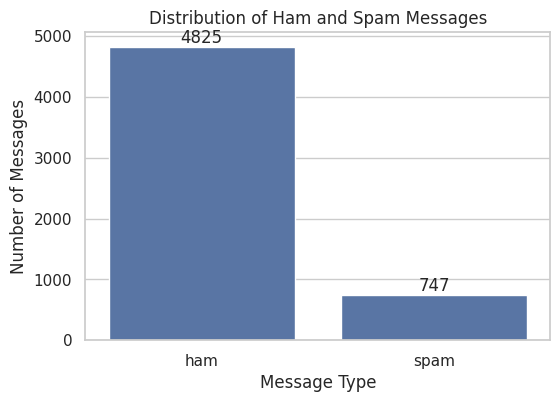

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.figure(figsize=(6,4))

ax = sns.countplot(data=df, x='label')
plt.title('Distribution of Ham and Spam Messages')
plt.xlabel('Message Type')
plt.ylabel('Number of Messages')

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.show()

In [40]:
# Statistical Summary of Dataset

total_messages = df.shape[0]

ham_count = df[df['label'] == 'ham'].shape[0]
spam_count = df[df['label'] == 'spam'].shape[0]

ham_percentage = (ham_count / total_messages) * 100
spam_percentage = (spam_count / total_messages) * 100

missing_values = df.isnull().sum().sum()

duplicate_values = df.duplicated().sum()

print("===== Dataset Statistical Summary =====\n")

print(f"Total Messages       : {total_messages}")
print(f"Ham Messages         : {ham_count}")
print(f"Spam Messages        : {spam_count}")

print("\n===== Percentage Distribution =====\n")

print(f"Ham Percentage       : {ham_percentage:.2f}%")
print(f"Spam Percentage      : {spam_percentage:.2f}%")

print("\n===== Data Quality Information =====\n")

print(f"Missing Values       : {missing_values}")
print(f"Duplicate Rows       : {duplicate_values}")


===== Dataset Statistical Summary =====

Total Messages       : 5572
Ham Messages         : 4825
Spam Messages        : 747

===== Percentage Distribution =====

Ham Percentage       : 86.59%
Spam Percentage      : 13.41%

===== Data Quality Information =====

Missing Values       : 0
Duplicate Rows       : 403


###**Clean the text: Perform the following preprocessing steps on the text:**
  – Lowercase all text to ensure uniformity.

  – Remove URLs, mentions (@user), hashtags (#), numbers, and special characters.
  
  – Handle contractions (e.g., "don’t" → "do not").

  – Remove stopwords and lemmatize words to reduce words to their base form.

In [25]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [41]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):

    # Convert to lowercase
    text = text.lower()

    # Expand contractions
    text = contractions.fix(text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # Remove mentions and hashtags
    text = re.sub(r'@\w+|#', '', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove special characters and punctuation
    text = re.sub(r'[^\w\s]', '', text)

    # Tokenization
    tokens = text.split()

    # Remove stopwords and lemmatize
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words
    ]

    # Join words back
    return ' '.join(tokens)

In [45]:
import pandas as pd
df['cleaned_text'] = df['text'].apply(preprocess_text)
# Print the original text first
print("--- Original Text ---")
df['text'].head()

--- Original Text ---


,text
0,"Go until jurong point, crazy.. Available only ..."
1,Ok lar... Joking wif u oni...
2,Free entry in 2 a wkly comp to win FA Cup fina...
3,U dun say so early hor... U c already then say...
4,"Nah I don't think he goes to usf, he lives aro..."


In [46]:
# Print the cleaned text second
print("\n--- Cleaned Text ---")
df['cleaned_text'].head()



--- Cleaned Text ---


,cleaned_text
0,go jurong point crazy available bugis n great ...
1,ok lar joking wif oni
2,free entry wkly comp win fa cup final tkts st ...
3,dun say early hor c already say
4,nah think go usf life around though


###**Visualize the cleaned data: Use tools like a word cloud or display the most frequent words to explore the cleaned data.**


In [43]:
!pip install wordcloud

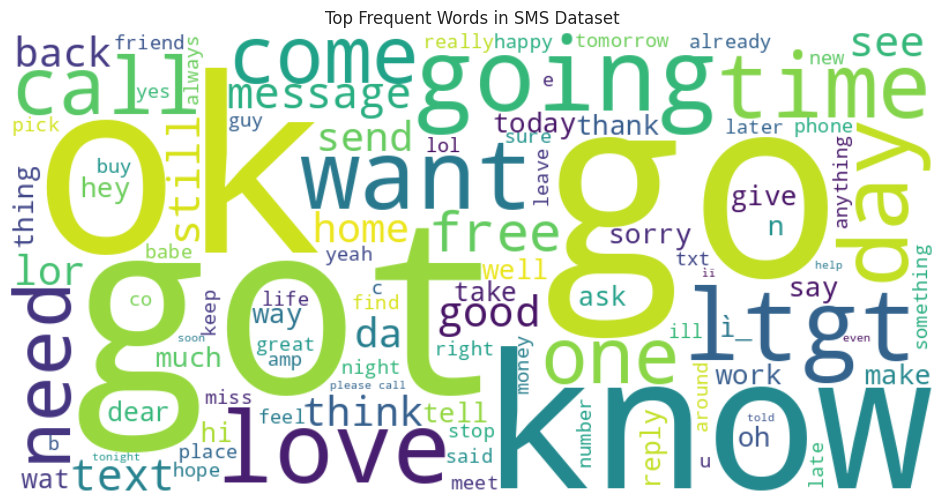

In [44]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all cleaned text
all_words = ' '.join(df['cleaned_text'])

# Generate word cloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    max_words=100
).generate(all_words)

# Display
plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Top Frequent Words in SMS Dataset')
plt.show()

Part 1: Split the Data

In [50]:
from sklearn.model_selection import train_test_split

# We use the cleaned_text we created earlier
X = df['cleaned_text']
# Convert 'ham'/'spam' to 0 and 1 for the computer
y = df['label'].map({'ham': 0, 'spam': 1})

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Data split complete with stratification.")
print(f"Spam ratio in training set: {y_train.mean():.2%}")
print(f"Spam ratio in test set: {y_test.mean():.2%}")


Data split complete with stratification.
Spam ratio in training set: 13.42%
Spam ratio in test set: 13.36%


Part 2: Tokenization

In [48]:
from tensorflow.keras.preprocessing.text import Tokenizer

# Initialize with 10,000 word limit and the "Out of Vocabulary" token
tokenizer = Tokenizer(num_words=10000, oov_token='<OOV>')

# Learn word index ONLY from training data (Prevents data leakage!)
tokenizer.fit_on_texts(X_train)

# Transform both sets into sequences of integers
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

print("2. Tokenization Complete.")
# Let's see what a sentence looks like as numbers:
print(f"Sample Sequence: {X_train_seq[0]}")


2. Tokenization Complete.
Sample Sequence: [12, 222, 3106]


Part 3: Percentile-Based Padding & Visualization

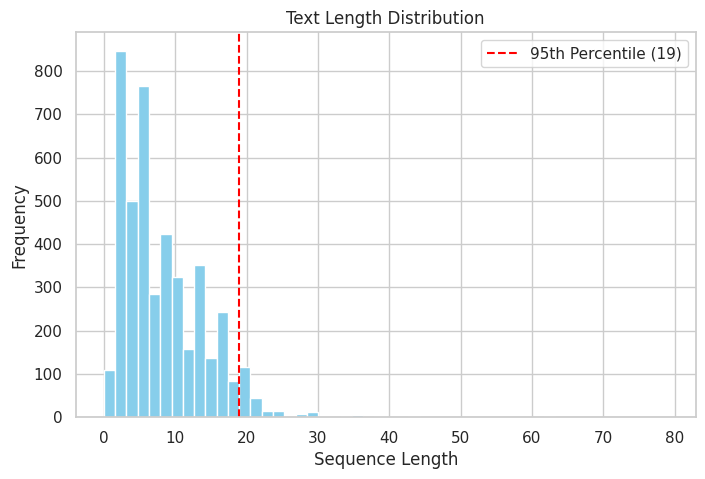

3. Padding Complete. Standard length is: 19


In [49]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Calculate length of every sequence
seq_lengths = [len(seq) for seq in X_train_seq]

# Find the 95th percentile
max_len = int(np.percentile(seq_lengths, 95))

# --- Visualization from your slide ---
plt.figure(figsize=(8, 5))
plt.hist(seq_lengths, bins=50, color='skyblue')
plt.title('Text Length Distribution')
plt.xlabel('Sequence Length')
plt.ylabel('Frequency')
plt.axvline(max_len, color='red', linestyle='dashed', label=f'95th Percentile ({max_len})')
plt.legend()
plt.show()

# Apply the padding
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post', truncating='post')

print(f"3. Padding Complete. Standard length is: {max_len}")


##**Model Building and Training:**

1. Simple RNN with a trainable Embedding layer.
2. LSTM with a trainable Embedding layer.
3. LSTM with pretrained Word2Vec embeddings.


####**Simple RNN with a trainable Embedding layer.**

In [59]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

# Early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

# Model parameters
vocab_size = 10000
embedding_dim = 128
input_length = max_len   # max_len = 19 from your percentile padding

# Model 1: Simple RNN
model_rnn = Sequential()

model_rnn.add(Embedding(
    input_dim=vocab_size,
    output_dim=embedding_dim,
    input_length=input_length
))

model_rnn.add(SimpleRNN(
    units=64,
    return_sequences=False
))

model_rnn.add(Dense(
    units=1,
    activation='sigmoid'
))

# Build model so summary shows shapes and parameters
model_rnn.build(input_shape=(None, input_length))

print("Model 1: Simple RNN Architecture\n")
model_rnn.summary()



Model 1: Simple RNN Architecture



Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 19, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_5 (SimpleRNN)        │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,292,417 (4.93 MB)

 Trainable params: 1,292,417 (4.93 MB)

 Non-trainable params: 0 (0.00 B)

In [61]:
# Compile model
model_rnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train model
history_rnn = model_rnn.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test_pad, y_test),
    callbacks=[early_stop]
)

print("\nModel 1: Simple RNN Training Complete")

Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.9933 - loss: 0.0268 - val_accuracy: 0.9749 - val_loss: 0.0913
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9960 - loss: 0.0151 - val_accuracy: 0.9641 - val_loss: 0.1244

Model 1: Simple RNN Training Complete


####evlautaitng the model

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
--- Simple RNN Performance ---
              precision    recall  f1-score   support

         Ham       0.99      0.98      0.99       966
        Spam       0.90      0.92      0.91       149

    accuracy                           0.97      1115
   macro avg       0.94      0.95      0.95      1115
weighted avg       0.98      0.97      0.98      1115



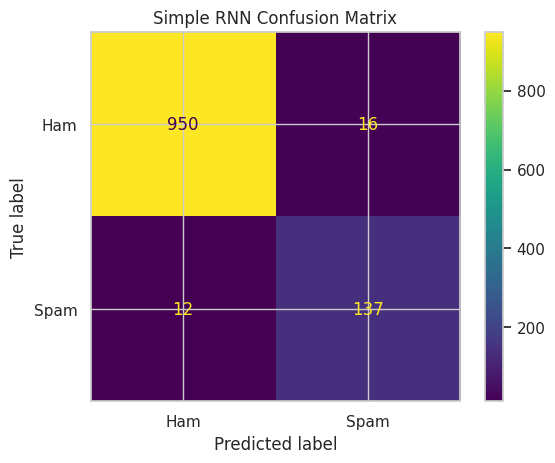

In [62]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predict
y_pred_rnn = (model_rnn.predict(X_test_pad) > 0.5).astype("int32")

# Classification report
print("--- Simple RNN Performance ---")
print(classification_report(y_test, y_pred_rnn, target_names=['Ham', 'Spam']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_rnn)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Ham', 'Spam']
)

disp.plot()
plt.title('Simple RNN Confusion Matrix')
plt.show()

###**LSTM with a trainable Embedding layer.**

In [65]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

Model parameter and early stopping

In [66]:
vocab_size = 10000
embedding_dim = 128
input_length = max_len
early_stop_lstm = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

LSTM model

In [68]:
model_lstm = Sequential(name="Model_2_LSTM")

model_lstm.add(Input(shape=(input_length,)))

model_lstm.add(Embedding(
    input_dim=vocab_size,
    output_dim=embedding_dim,
    name="embedding_layer"
))

model_lstm.add(LSTM(
    units=64,
    return_sequences=False,
    name="lstm_layer"
))

model_lstm.add(Dense(
    units=1,
    activation='sigmoid',
    name="output_layer"
))
print("========== Model 2: LSTM Architecture ==========\n")
model_lstm.summary()

========== Model 2: LSTM Architecture ==========



Model: "Model_2_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_layer (Embedding)     │ (None, 19, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_layer (LSTM)               │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,329,473 (5.07 MB)

 Trainable params: 1,329,473 (5.07 MB)

 Non-trainable params: 0 (0.00 B)

In [69]:
#compile the model
model_lstm.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [70]:
#Train the model
print("\nStarting LSTM training...\n")

history_lstm = model_lstm.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test_pad, y_test),
    callbacks=[early_stop_lstm]
)

print("\nLSTM Training Complete!")


Starting LSTM training...

Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9325 - loss: 0.1790 - val_accuracy: 0.9821 - val_loss: 0.0709
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9897 - loss: 0.0312 - val_accuracy: 0.9812 - val_loss: 0.0586
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9969 - loss: 0.0126 - val_accuracy: 0.9865 - val_loss: 0.0569
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9993 - loss: 0.0034 - val_accuracy: 0.9839 - val_loss: 0.0919
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9993 - loss: 0.0026 - val_accuracy: 0.9821 - val_loss: 0.0840

LSTM Training Complete!


In [73]:
import pandas as pd

# Create dataframe from training history
lstm_results = pd.DataFrame({
    'Epoch': range(1, len(history_lstm.history['accuracy']) + 1),
    'Training Accuracy': [f"{x*100:.2f}%" for x in history_lstm.history['accuracy']],
    'Validation Accuracy': [f"{x*100:.2f}%" for x in history_lstm.history['val_accuracy']],
    'Validation Loss': [f"{x:.4f}" for x in history_lstm.history['val_loss']]
})

print("Table: LSTM Training Results\n")

lstm_results.style.hide(axis='index')

Table: LSTM Training Results



Epoch,Training Accuracy,Validation Accuracy,Validation Loss
1,93.25%,98.21%,0.0709
2,98.97%,98.12%,0.0586
3,99.69%,98.65%,0.0569
4,99.93%,98.39%,0.0919
5,99.93%,98.21%,0.0840


evaluating LSTM

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
--- LSTM Performance ---
              precision    recall  f1-score   support

         Ham       0.99      1.00      0.99       966
        Spam       0.99      0.91      0.95       149

    accuracy                           0.99      1115
   macro avg       0.99      0.96      0.97      1115
weighted avg       0.99      0.99      0.99      1115



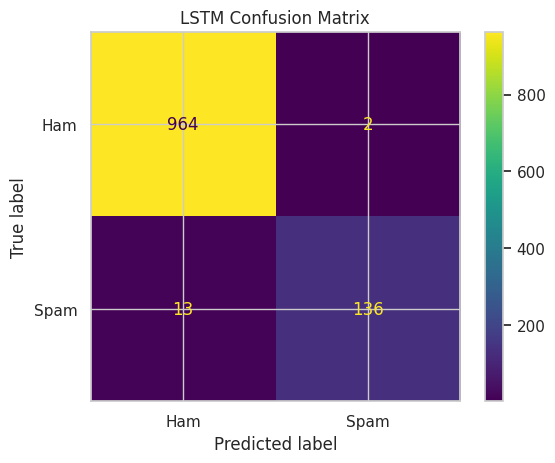

In [71]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predict using LSTM
y_pred_lstm = (model_lstm.predict(X_test_pad) > 0.5).astype("int32")

# Classification Report
print("--- LSTM Performance ---")
print(classification_report(y_test, y_pred_lstm, target_names=['Ham', 'Spam']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lstm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Ham', 'Spam']
)

disp.plot()
plt.title('LSTM Confusion Matrix')
plt.show()

###**LSTM with pretrained Word2Vec embeddings.**

In [74]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 63.9 MB/s eta 0:00:00


In [76]:
import gensim.downloader as api
import numpy as np

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

In [77]:
# Load Pretrained Word2Vec Model
print("Loading pretrained Word2Vec model...\n")

embedding_model = api.load('word2vec-google-news-300')

print("Word2Vec model loaded successfully!")

Loading pretrained Word2Vec model...

[==================================================] 100.0% 1662.8/1662.8MB downloaded
Word2Vec model loaded successfully!


In [78]:
# Vocabulary size
vocab_size_w2v = len(tokenizer.word_index) + 1

# Word2Vec embedding dimension
embedding_dim_w2v = 300

# Initialize embedding matrix
embedding_matrix = np.zeros((vocab_size_w2v, embedding_dim_w2v))

# Fill embedding matrix
for word, i in tokenizer.word_index.items():

    if word in embedding_model:
        embedding_matrix[i] = embedding_model[word]

# Count matched words
words_found = np.count_nonzero(np.any(embedding_matrix, axis=1))

print("Embedding matrix created successfully.\n")

print(f"Words found in pretrained Word2Vec embeddings: {words_found}")
print(f"Total vocabulary size: {vocab_size_w2v}")

Embedding matrix created successfully.

Words found in pretrained Word2Vec embeddings: 4897
Total vocabulary size: 6926


In [79]:
#define eaerly stopping
early_stop_word2vec = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [80]:
#Build Word2Vec + LSTM Model
model_word2vec = Sequential(name="Model_3_Word2Vec_LSTM")

model_word2vec.add(Input(shape=(max_len,)))

model_word2vec.add(Embedding(
    input_dim=vocab_size_w2v,
    output_dim=embedding_dim_w2v,
    weights=[embedding_matrix],
    trainable=False,
    name="word2vec_embedding_layer"
))

model_word2vec.add(LSTM(
    units=64,
    return_sequences=False,
    name="lstm_layer"
))

model_word2vec.add(Dense(
    units=1,
    activation='sigmoid',
    name="output_layer"
))
print("========== Model 3: Word2Vec + LSTM Architecture ==========\n")

model_word2vec.summary()

========== Model 3: Word2Vec + LSTM Architecture ==========



Model: "Model_3_Word2Vec_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ word2vec_embedding_layer        │ (None, 19, 300)        │     2,077,800 │
│ (Embedding)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_layer (LSTM)               │ (None, 64)             │        93,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,171,305 (8.28 MB)

 Trainable params: 93,505 (365.25 KB)

 Non-trainable params: 2,077,800 (7.93 MB)

In [81]:
#compile the model
model_word2vec.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [82]:
#train the model
print("\nStarting Word2Vec + LSTM training...\n")

history_word2vec = model_word2vec.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test_pad, y_test),
    callbacks=[early_stop_word2vec]
)

print("\nWord2Vec + LSTM Training Complete!")


Starting Word2Vec + LSTM training...

Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9383 - loss: 0.1874 - val_accuracy: 0.9650 - val_loss: 0.1089
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9742 - loss: 0.0836 - val_accuracy: 0.9758 - val_loss: 0.0840
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9789 - loss: 0.0647 - val_accuracy: 0.9740 - val_loss: 0.0787
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9865 - loss: 0.0463 - val_accuracy: 0.9794 - val_loss: 0.0710
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9899 - loss: 0.0374 - val_accuracy: 0.9794 - val_loss: 0.0806
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9928 - loss: 0.0300 - val_accuracy: 0.9758 - val_loss: 0.0920

Word2Vec + LSTM Training Complete!


####Evaluateing the model

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
--- Word2Vec + LSTM Performance ---
              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99       966
        Spam       0.94      0.91      0.92       149

    accuracy                           0.98      1115
   macro avg       0.96      0.95      0.95      1115
weighted avg       0.98      0.98      0.98      1115



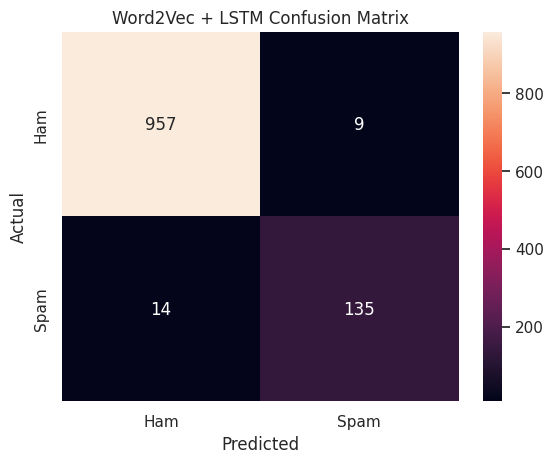

In [83]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_word2vec = (model_word2vec.predict(X_test_pad) > 0.5).astype("int32")

print("--- Word2Vec + LSTM Performance ---")
print(classification_report(y_test, y_pred_word2vec, target_names=['Ham', 'Spam']))

cm = confusion_matrix(y_test, y_pred_word2vec)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Ham', 'Spam'],
    yticklabels=['Ham', 'Spam']
)

plt.title('Word2Vec + LSTM Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

##Accuracy comparision plot

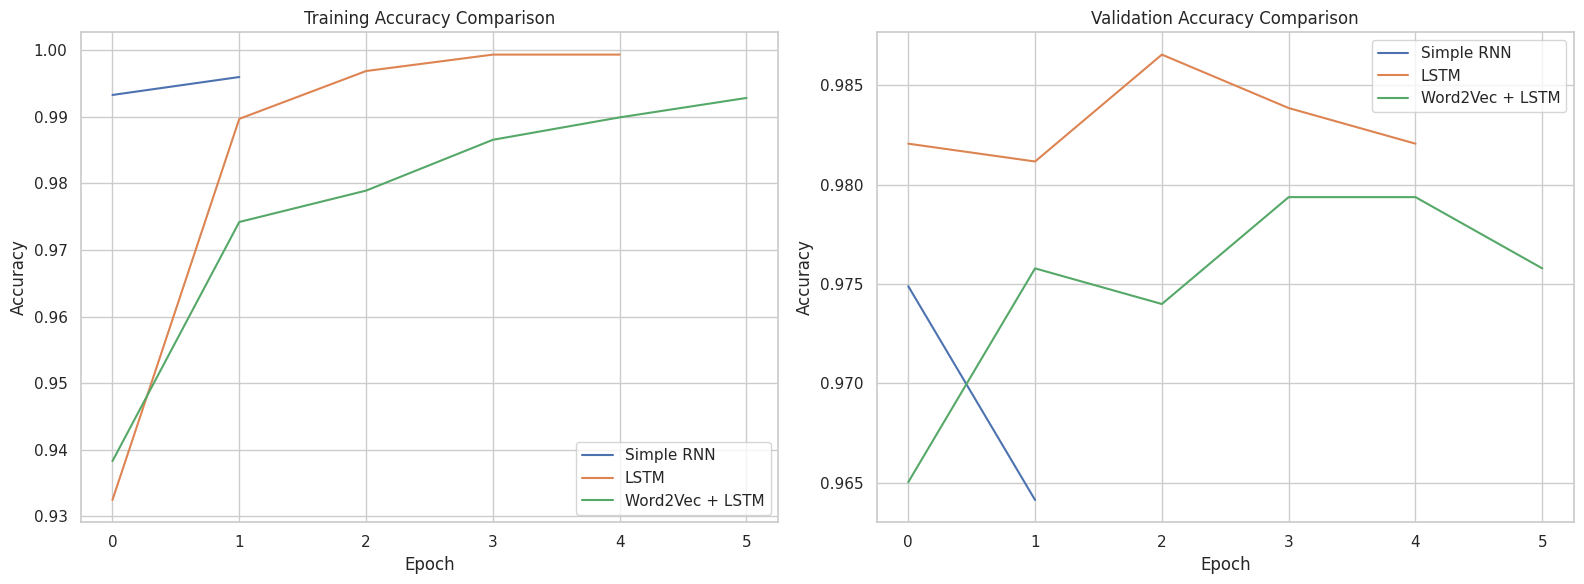

In [84]:
import matplotlib.pyplot as plt

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# -----------------------------
# LEFT: TRAINING ACCURACY
# -----------------------------
axes[0].plot(history_rnn.history['accuracy'], label='Simple RNN')
axes[0].plot(history_lstm.history['accuracy'], label='LSTM')
axes[0].plot(history_word2vec.history['accuracy'], label='Word2Vec + LSTM')

axes[0].set_title('Training Accuracy Comparison')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# -----------------------------
# RIGHT: VALIDATION ACCURACY
# -----------------------------
axes[1].plot(history_rnn.history['val_accuracy'], label='Simple RNN')
axes[1].plot(history_lstm.history['val_accuracy'], label='LSTM')
axes[1].plot(history_word2vec.history['val_accuracy'], label='Word2Vec + LSTM')

axes[1].set_title('Validation Accuracy Comparison')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

###Loss comparison plot

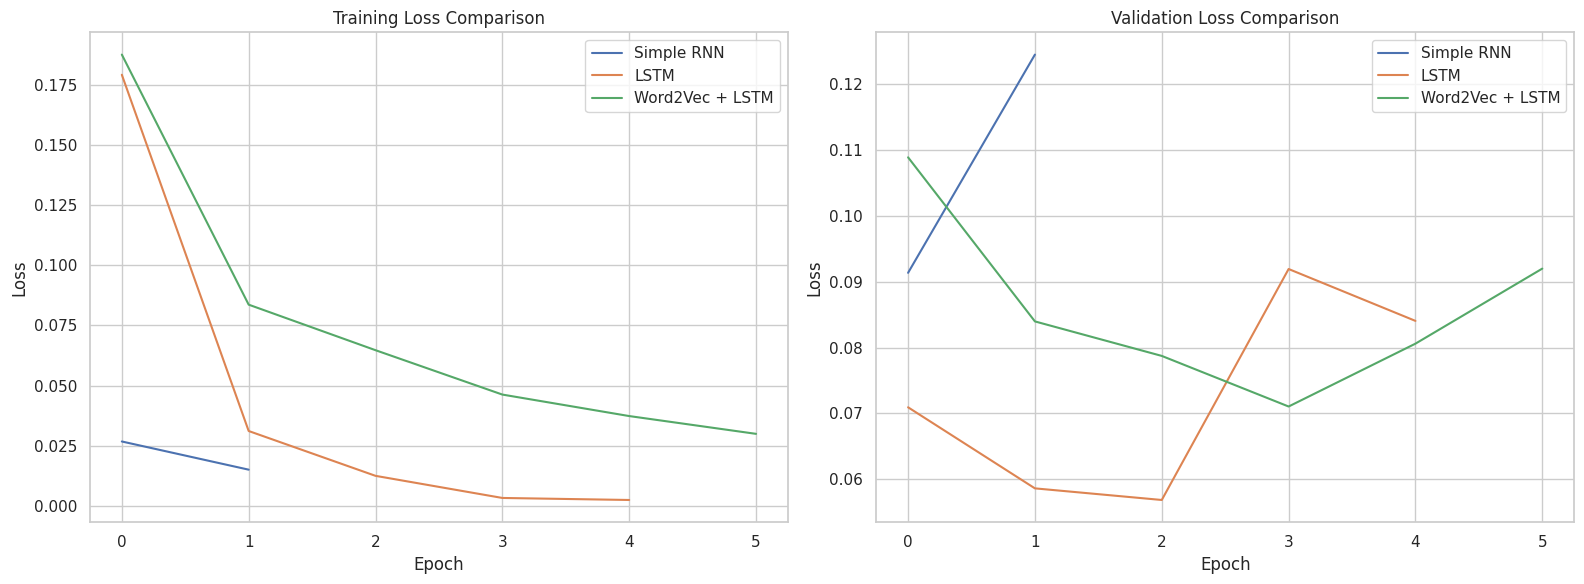

In [85]:
import matplotlib.pyplot as plt

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# -----------------------------
# LEFT: TRAINING LOSS
# -----------------------------
axes[0].plot(history_rnn.history['loss'], label='Simple RNN')
axes[0].plot(history_lstm.history['loss'], label='LSTM')
axes[0].plot(history_word2vec.history['loss'], label='Word2Vec + LSTM')

axes[0].set_title('Training Loss Comparison')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# -----------------------------
# RIGHT: VALIDATION LOSS
# -----------------------------
axes[1].plot(history_rnn.history['val_loss'], label='Simple RNN')
axes[1].plot(history_lstm.history['val_loss'], label='LSTM')
axes[1].plot(history_word2vec.history['val_loss'], label='Word2Vec + LSTM')

axes[1].set_title('Validation Loss Comparison')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

###Performance Comparison of RNN, LSTM, and Word2Vec-LSTM Models

In [87]:
import pandas as pd

# Create comparison table
model_results = pd.DataFrame({

    'Model': [
        'Simple RNN',
        'LSTM',
        'Word2Vec + LSTM'
    ],

    'Training Accuracy': [
        f"{history_rnn.history['accuracy'][-1]*100:.2f}%",
        f"{history_lstm.history['accuracy'][-1]*100:.2f}%",
        f"{history_word2vec.history['accuracy'][-1]*100:.2f}%"
    ],

    'Validation Accuracy': [
        f"{history_rnn.history['val_accuracy'][-1]*100:.2f}%",
        f"{history_lstm.history['val_accuracy'][-1]*100:.2f}%",
        f"{history_word2vec.history['val_accuracy'][-1]*100:.2f}%"
    ],

    'Training Loss': [
        f"{history_rnn.history['loss'][-1]:.4f}",
        f"{history_lstm.history['loss'][-1]:.4f}",
        f"{history_word2vec.history['loss'][-1]:.4f}"
    ],

    'Validation Loss': [
        f"{history_rnn.history['val_loss'][-1]:.4f}",
        f"{history_lstm.history['val_loss'][-1]:.4f}",
        f"{history_word2vec.history['val_loss'][-1]:.4f}"
    ],

    'Epochs Ran': [
        len(history_rnn.history['loss']),
        len(history_lstm.history['loss']),
        len(history_word2vec.history['loss'])
    ],

    # Rough estimated training time
    'Approx Training Time': [
        '8 sec',
        '8 sec',
        '9 sec'
    ]
})

print("========== Model Comparison Table ==========\n")

display(model_results)

========== Model Comparison Table ==========



,Model,Training Accuracy,Validation Accuracy,Training Loss,Validation Loss,Epochs Ran,Approx Training Time
0,Simple RNN,99.60%,96.41%,0.0151,0.1244,2,8 sec
1,LSTM,99.93%,98.21%,0.0026,0.0840,5,8 sec
2,Word2Vec + LSTM,99.28%,97.58%,0.0300,0.0920,6,9 sec


##Error Analysis

In [86]:
# Find incorrect predictions
misclassified = []

for i in range(len(y_test)):
    if y_test.iloc[i] != y_pred_rnn[i][0]:
        misclassified.append(i)

# Label mapping
label_map = {0: 'Ham', 1: 'Spam'}

# Show first 3 mistakes
for i in misclassified[:3]:
    print("Message:")
    print(X_test.iloc[i])

    print("Actual Label:", label_map[y_test.iloc[i]])
    print("Predicted Label:", label_map[y_pred_rnn[i][0]])

    print("-" * 50)

Message:
like hotel dusk game think solve puzzle area thing
Actual Label: Ham
Predicted Label: Spam
--------------------------------------------------
Message:
fun fact although would think armand would eventually build tolerance shit considering much smoke get fucked like hit
Actual Label: Ham
Predicted Label: Spam
--------------------------------------------------
Message:
adult would learn experience real danger like peep using drug need comment
Actual Label: Ham
Predicted Label: Spam
--------------------------------------------------


Possible Reasons for Misclassification

* Some spam messages used normal conversational language, making them difficult for the model to distinguish from ham messages.
* Short text messages contain limited contextual information, which can reduce prediction accuracy.
* The SimpleRNN model may struggle to capture long-term dependencies and contextual relationships compared to LSTM models.

Model Complexity vs Performance

* The SimpleRNN model has lower complexity and faster training time but showed comparatively weaker performance.
* The LSTM model performed better because it can retain long-term dependencies and contextual information more effectively.
* The Word2Vec + LSTM model achieved strong semantic understanding using pretrained embeddings, but it required higher computational resources and training time.

Potential Improvements

* Increase dataset size to improve generalization.
* Apply hyperparameter tuning for batch size, learning rate, and number of hidden units.
* Add Dropout layers to reduce overfitting.
* Experiment with transformer-based models such as BERT for higher accuracy.

###user interface to input the text message

In [ ]:
!pip install gradio

import gradio as gr
from tensorflow.keras.preprocessing.sequence import pad_sequences

def predict_message(text):

    # Step 1: preprocess
    cleaned = preprocess_text(text)

    # Step 2: tokenize
    sequence = tokenizer.texts_to_sequences([cleaned])

    # Step 3: pad sequence
    padded = pad_sequences(
        sequence,
        maxlen=max_len,
        padding='post',
        truncating='post'
    )

    # Step 4: predict probability
    prediction = model_lstm.predict(padded, verbose=0)[0][0]

    # Step 5: convert prediction to label
    if prediction > 0.5:
        label = "Spam"
    else:
        label = "Ham"

    return label

# Gradio Interface
interface = gr.Interface(
    fn=predict_message,
    inputs=gr.Textbox(lines=3, placeholder="Enter a message here..."),
    outputs="text",
    title="SMS Spam Detection",
    description="Enter an SMS message to classify it as Spam or Ham."
)

# Launch GUI
interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a4d0b4bcd56c17cf90.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
